# Data Processing & Analysis

## Overview
This notebook presents the data preprocessing pipeline for the LegalCon dataset, including cleaning, normalization, validation, and stratified splitting. The goal is to construct a high-quality dataset for three tasks: manipulation detection, manipulator identification, and technique classification.


## 1. Setup & Imports

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sys
import re
import numpy as np

## 2. Dataset Overview

### 2.1 Load and Examine Dataset

In [112]:
df = pd.read_csv("/kaggle/input/legalcon-dataset/LegalCon-Dataset.csv")
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   IDs                      1038 non-null   int64 
 1   Dialogue                 1038 non-null   object
 2   Manipulative             1038 non-null   int64 
 3   Primary Manipulator      635 non-null    object
 4   Manipulation Techniques  636 non-null    object
dtypes: int64(2), object(3)
memory usage: 40.7+ KB


,IDs,Dialogue,Manipulative,Primary Manipulator,Manipulation Techniques
0,804,**[Judge]**\nWelcome back to The People's Cour...,1,plaintiff,"gaslighting, deflection"
1,154,Judge: you shouldn't have a problem paying the...,1,defendant,"Minimization, Deflection"
2,566,Judge: But it says a notice to appear under Se...,0,NaN,NaN
3,594,"Judge: All parties, please raise your right ha...",1,defendant,"minimization,Deflection, dismissal"
4,116,"Judge:\nOkay, Elias Samas.\n\nPlaintiff:\nThat...",1,defendant,minimization deflection persuasion
5,780,Judge\n-- but I just want to understand what's...,0,NaN,NaN
6,558,"Judge: All parties, please welcome back to the...",1,plaintiff,"deflection, minimization, persuasion"
7,762,"Judge: ""But you had told him, 'I'm pregnant ei...",1,defendant,"Minimization, deflection"
8,656,"Judge: Tracy Unique Alexander. Yes, you are su...",1,defendant,"character attack, playing the victim, gaslight..."
9,956,Judge: So all of this money and he hasn't give...,1,defendant,"Minimization, Evasion"


In [113]:
df.nunique()

IDs                        1038
Dialogue                   1035
Manipulative                  2
Primary Manipulator          11
Manipulation Techniques     485
dtype: int64

### Identify Missing Values and Data Quality Issues

In [114]:
print("Missing values in each column:")
print(df.isnull().sum())
print("\nMissing values percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))
print(f"\nTotal rows with any missing values: {df.isnull().any(axis=1).sum()}")

Missing values in each column:
IDs                          0
Dialogue                     0
Manipulative                 0
Primary Manipulator        403
Manipulation Techniques    402
dtype: int64

Missing values percentage:
IDs                         0.00
Dialogue                    0.00
Manipulative                0.00
Primary Manipulator        38.82
Manipulation Techniques    38.73
dtype: float64

Total rows with any missing values: 403


Manipulative distribution:
              Count  Percent (%)
Manipulative                    
1               636        61.27
0               402        38.73


Text(0, 0.5, 'Count')

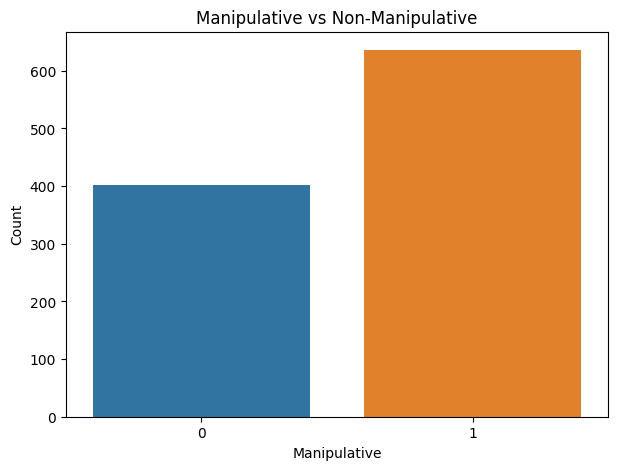

In [115]:
counts = df['Manipulative'].value_counts()
percent = (counts / counts.sum() * 100).round(2)

print("Manipulative distribution:")
print(pd.DataFrame({"Count": counts, "Percent (%)": percent}))

plt.figure(figsize=(7, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Manipulative vs Non-Manipulative')
plt.ylabel('Count')

## 3. Data Cleaning

### 3.1 Duplicate Removal
Removed duplicate dialogues (keep first occurrence)

In [116]:
dup_mask = df["Dialogue"].duplicated(keep=False)
dup_dialogues = df[dup_mask].sort_values("Dialogue")

print(f"Duplicate rows: {dup_mask.sum()}")
print(f"Duplicate dialogue values: {dup_dialogues['Dialogue'].nunique()}")

dup_dialogues

Duplicate rows: 6
Duplicate dialogue values: 3


,IDs,Dialogue,Manipulative,Primary Manipulator,Manipulation Techniques
78,272,"Judge:\nI think that the concern raised, thoug...",0,NaN,NaN
608,462,"Judge:\nI think that the concern raised, thoug...",0,NaN,NaN
442,776,"Judge: All parties, please raise your right ha...",1,plaintiff,"deflection, exxageration"
613,740,"Judge: All parties, please raise your right ha...",1,plaintiff,exaggeration
912,14,"Judge: This is the plaintiff, Shawn Dale Tatum...",1,defendant,"deflection, playing the victim"
939,773,"Judge: This is the plaintiff, Shawn Dale Tatum...",1,plaintiff,"deflection, playing the victim,gaslighting, ev..."


In [117]:
dup_count = df['Dialogue'].duplicated().sum()

df = df.drop_duplicates(subset=['Dialogue'], keep='first')

print(f"Removed {dup_count} duplicates → {len(df)} rows remaining")
print(f"Missing Dialogue: {df['Dialogue'].isna().sum()}")

Removed 3 duplicates → 1035 rows remaining
Missing Dialogue: 0


#### Dialogue Length Analysis


Word Count Statistics:
count    1035.000000
mean      880.252174
std       503.051237
min        35.000000
25%       642.500000
50%       931.000000
75%      1135.500000
max      2742.000000
Name: Dialogue, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Frequency')

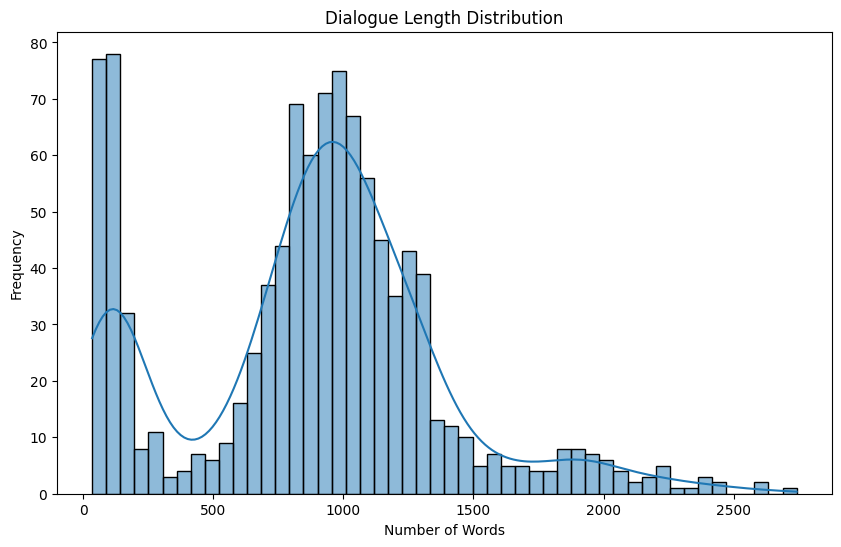

In [118]:
word_count = df['Dialogue'].astype(str).str.split().str.len()

print("Word Count Statistics:")
print(word_count.describe())

plt.figure(figsize=(10, 6))
sns.histplot(word_count, bins=50, kde=True)
plt.title('Dialogue Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

### 3.2. Dialogue Standardization
- Normalize speaker roles (e.g., `[Judge]` → `Judge:`)
- Remove formatting artifacts (bold, brackets, noise)
- Enforce consistent `Role: Content` structure

In [119]:
ROLE = r'(Judge|Plaintiff|Defendant|Lawyer of Plaintiff|Lawyer of Defendant|Bailiff)'

def standardize_to_pure_roles(text):
    if not isinstance(text, str):
        return ""

    # Basic normalize
    text = re.sub(rf'\[({ROLE}|Lawyer.*?)\]', r'\1:', text)
    text = text.replace("**", "").replace('\r\n', '\n').replace('\r', '\n')

    # Normalize "Role (Name)" → "Role:"
    text = re.sub(rf'^{ROLE}(\s\(.*?\))?[:]?\s*\n?', r'\1: ', text, flags=re.MULTILINE)

    # Remove extra empty lines
    text = re.sub(r'\n\s*\n+', '\n', text)

    lines = []
    for l in map(str.strip, text.split('\n')):
        if not l:
            continue

        # Remove leftover "(Name)"
        l = re.sub(rf'^{ROLE}(\s\(.*?\))?:', r'\1:', l)

        # Ensure "Role: content"
        if ":" not in l[:50]:
            l = re.sub(rf'^{ROLE}\s+(.*)', r'\1: \2', l)

        # Clean quotes & noise
        l = re.sub(r'^([^:]+:\s*)"(.*)"$', r'\1\2', l)
        l = l.replace("(Laughter.)", "").replace("(Laughter)", "")

        # Normalize spacing
        l = re.sub(r'(\w+:)\s+', r'\1 ', l)

        lines.append(l)

    return "\n".join(lines)

In [120]:
df['Dialogue'] = df['Dialogue'].apply(standardize_to_pure_roles)
df.head(20)

,IDs,Dialogue,Manipulative,Primary Manipulator,Manipulation Techniques
0,804,Judge: Welcome back to The People's Court. Nex...,1,plaintiff,"gaslighting, deflection"
1,154,Judge: you shouldn't have a problem paying the...,1,defendant,"Minimization, Deflection"
2,566,Judge: But it says a notice to appear under Se...,0,NaN,NaN
3,594,"Judge: All parties, please raise your right ha...",1,defendant,"minimization,Deflection, dismissal"
4,116,"Judge: Okay, Elias Samas.\nPlaintiff: That's m...",1,defendant,minimization deflection persuasion
5,780,Judge: -- but I just want to understand what's...,0,NaN,NaN
6,558,"Judge: All parties, please welcome back to the...",1,plaintiff,"deflection, minimization, persuasion"
7,762,"Judge: But you had told him, 'I'm pregnant eig...",1,defendant,"Minimization, deflection"
8,656,"Judge: Tracy Unique Alexander. Yes, you are su...",1,defendant,"character attack, playing the victim, gaslight..."
9,956,Judge: So all of this money and he hasn't give...,1,defendant,"Minimization, Evasion"


### 3.3 Primary Manipulator Normalization
- Standardize labels (case, whitespace, typos)
- Remove rare categories (e.g., lawyer roles)

In [121]:
col = df['Primary Manipulator']

print(f"Total rows: {len(df)}")
print(f"Unique values: {col.nunique()}")
print("\nValues:")
print(col.unique())

Total rows: 1035
Unique values: 11

Values:
['plaintiff' 'defendant' nan 'Defendant' 'defendent' 'Plaintiff'
 'plaintiff ' 'pLaintiff' 'defendanr' "Plaintiff's lawyer"
 "Defendant's Lawyer" ' defendant']


In [122]:
col = df["Primary Manipulator"]

df["Primary Manipulator"] = (
    col.str.strip()
       .str.lower()
       .replace({"defendent": "defendant", "defendanr": "defendant"})
       .str.title()
)

df["Primary Manipulator"].unique()

array(['Plaintiff', 'Defendant', nan, "Plaintiff'S Lawyer",
       "Defendant'S Lawyer"], dtype=object)

In [123]:
print("Validation after normalization:")
print(f"Unique values count: {df['Primary Manipulator'].nunique()}")
print(f"Missing values: {df['Primary Manipulator'].isnull().sum()}")

Validation after normalization:
Unique values count: 4
Missing values: 402


Primary Manipulator distribution:
                     Count  Percent (%)
Primary Manipulator                    
Defendant              439        42.42
Plaintiff              192        18.55
Plaintiff'S Lawyer       1         0.10
Defendant'S Lawyer       1         0.10


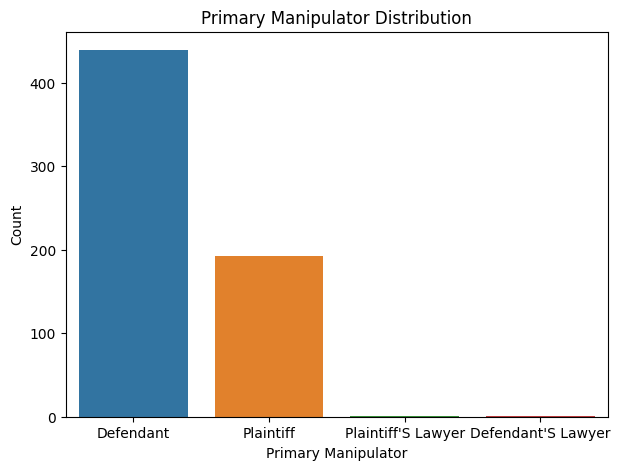

In [124]:
col = df['Primary Manipulator']

counts = col.value_counts()
percent = (counts / len(df) * 100).round(2)

print("Primary Manipulator distribution:")
print(pd.DataFrame({"Count": counts, "Percent (%)": percent}))

plt.figure(figsize=(7, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Primary Manipulator Distribution')
plt.ylabel('Count')
plt.show()

In [125]:
mask = ~df['Primary Manipulator'].str.lower().str.contains('lawyer', na=False)

before = len(df)
df = df[mask]

removed = before - len(df)

print(f"Removed {removed} lawyer entries → {len(df)} rows remaining\n")

counts = df['Primary Manipulator'].value_counts()
percent = (counts / counts.sum() * 100).round(2)

print(pd.DataFrame({"Count": counts, "Percent (%)": percent}))

Removed 2 lawyer entries → 1033 rows remaining

                     Count  Percent (%)
Primary Manipulator                    
Defendant              439        69.57
Plaintiff              192        30.43


### 3.4 Manipulation Techniques Cleaning

- Normalize to 11 canonical techniques
- Fix typos and variants
- Extract multi-label annotations
- Sort techniques in fixed order


In [126]:
col = df['Manipulation Techniques']

print(f"Unique values: {col.nunique()}")
print(f"Missing values: {col.isna().sum()}\n")

print("Sample values (first 20):")
print(col.unique()[:20])

Unique values: 483
Missing values: 401

Sample values (first 20):
[' gaslighting, deflection' 'Minimization, Deflection' nan
 'minimization,Deflection, dismissal' 'minimization deflection persuasion'
 'deflection, minimization, persuasion' 'Minimization, deflection'
 'character attack, playing the victim, gaslighting, dismissal, deflection'
 'Minimization, Evasion' 'Minimization,Deflection ,Emotional Framing'
 'evasion, persuasion' 'Deflection, Guilt Tripping'
 ' Gaslighting,Minimization,Deflection' 'minimization, gaslighting'
 'playing the victim' 'minimization, deflection, persuasion'
 'emotional appeal, deflection'
 'Deflection , Minimization, Emotional Appeal, Gaslighting' ', deflection'
 'deflection, dismissal, minimization, exaggeration, emotional appeal']


In [127]:
canonical_techniques_ordered = {
    "gaslighting": 1, "guilt tripping": 2, "persuasion": 3, "evasion": 4,
    "framing the narrative": 5, "dismissal": 6, "character attack": 7,
    "deflection": 8, "minimization": 9, "emotional appeal": 10,
    "playing the victim": 11
}

normalization_map = {
    "playing the victim role": "playing the victim",
    "victim playing": "playing the victim",
    "plaing the victim": "playing the victim",
    "guilt-tripping": "guilt tripping",
    "guilttripping": "guilt tripping",
    "guilt - tripping": "guilt tripping",
    "emotional appealing": "emotional appeal",
    "emtional appeal": "emotional appeal",
    "emotion appeal": "emotional appeal",
    "appeal to emotion": "emotional appeal",
    "emotional blackmailing": "emotional appeal",
    "framing narrative": "framing the narrative",
    "gasligting": "gaslighting",
    "defelction": "deflection",
}

print(f"Canonical techniques: {len(canonical_techniques_ordered)}")
print(f"Normalization rules: {len(normalization_map)}")

Canonical techniques: 11
Normalization rules: 14


In [128]:
allowed = set(canonical_techniques_ordered)

multi_word = sorted([t for t in allowed if ' ' in t], key=len, reverse=True)
single_word = sorted([t for t in allowed if ' ' not in t], key=len, reverse=True)

print(f"Multi-word ({len(multi_word)}):", multi_word)
print(f"Single-word ({len(single_word)}):", single_word)

Multi-word (5): ['framing the narrative', 'playing the victim', 'character attack', 'emotional appeal', 'guilt tripping']
Single-word (6): ['minimization', 'gaslighting', 'deflection', 'persuasion', 'dismissal', 'evasion']


In [129]:
def clean_manipulation_techniques(text):
    if pd.isna(text):
        return np.nan

    text = re.sub(r'[.,;]+$', '', re.sub(r'\s+', ' ', str(text).lower()).strip())
    if not text:
        return np.nan

    # Normalize multi-word variants
    temp = text
    for v, c in normalization_map.items():
        if ' ' in c:
            temp = re.sub(rf'\b{re.escape(v)}\b', c, temp)

    found, spans = set(), []

    # Extract multi-word techniques (avoid overlap)
    for tech in multi_word_techniques:
        for m in re.finditer(rf'\b{re.escape(tech)}\b', temp):
            s, e = m.span()
            if not any(max(s, ps) < min(e, pe) for ps, pe in spans):
                found.add(tech)
                spans.append((s, e))

    # Remove matched spans → get remaining text
    spans.sort()
    remaining = []
    last = 0
    for s, e in spans:
        remaining.append(temp[last:s])
        last = e
    remaining.append(temp[last:])
    remaining = ' '.join(remaining)

    # Extract single-word techniques
    for w in re.split(r'\s*[,&/]\s*|\s+', remaining):
        w = w.strip('.,;')
        if not w:
            continue
        w = normalization_map.get(w, w)
        if w in single_word_techniques:
            found.add(w)

    if not found:
        return np.nan

    return ', '.join(sorted(found, key=lambda t: canonical_techniques_ordered[t]))

In [130]:
# Apply cleaning function
print("Cleaning 'Manipulation Techniques' column...")
print(f"Original unique values: {df['Manipulation Techniques'].nunique()}")
print(f"Original missing values: {df['Manipulation Techniques'].isnull().sum()}")

# Store original for comparison
df['Original_Techniques'] = df['Manipulation Techniques']

# Apply cleaning
df['Manipulation Techniques'] = df['Manipulation Techniques'].apply(clean_manipulation_techniques)

print(f"\nCleaning complete!")
print(f"After cleaning unique values: {df['Manipulation Techniques'].nunique()}")
print(f"After cleaning missing values: {df['Manipulation Techniques'].isnull().sum()}")

Cleaning 'Manipulation Techniques' column...
Original unique values: 483
Original missing values: 401

Cleaning complete!
After cleaning unique values: 161
After cleaning missing values: 404


In [131]:
print("=== CLEANING VALIDATION ===\n")

changed = df[df['Original_Techniques'] != df['Manipulation Techniques']]

print("Sample Before vs After Cleaning:")

if changed.empty:
    print("No changes detected")
else:
    for _, row in changed.head(10).iterrows():
        print(f"\nBefore: {row['Original_Techniques']}")
        print(f"After:  {row['Manipulation Techniques']}")

print("\nTechnique Distribution (cleaned):")
print(df['Manipulation Techniques'].value_counts().head(20))

=== CLEANING VALIDATION ===

Sample Before vs After Cleaning:

Before:  gaslighting, deflection
After:  gaslighting, deflection

Before: Minimization, Deflection
After:  deflection, minimization

Before: nan
After:  nan

Before: minimization,Deflection, dismissal
After:  dismissal, deflection, minimization

Before: minimization deflection persuasion
After:  persuasion, deflection, minimization

Before: nan
After:  nan

Before: deflection, minimization, persuasion
After:  persuasion, deflection, minimization

Before: Minimization, deflection
After:  deflection, minimization

Before: character attack, playing the victim, gaslighting, dismissal, deflection
After:  gaslighting, dismissal, character attack, deflection, playing the victim

Before: Minimization, Evasion
After:  evasion, minimization

Technique Distribution (cleaned):
Manipulation Techniques
deflection                                                       35
deflection, minimization                                         33
e

### 3.5 Data Validation
- Remove inconsistent samples:
  - `Manipulative = 1` but no techniques

In [132]:
mask = (df['Manipulation Techniques'].isna()) & (df['Manipulative'] == 1)

original_rows = len(df)
rows_deleted = mask.sum()

df = df[~mask].copy()

print(f"Removed {rows_deleted} inconsistent rows ({rows_deleted/original_rows:.2%}) → {len(df)} rows remaining")

Removed 3 inconsistent rows (0.29%) → 1030 rows remaining


In [133]:
if rows_deleted > 0:
    print("\n=== DELETED ROWS SAMPLE ===")
    print("\nFirst 5 deleted rows:")
    display_cols = ['Manipulative', 'Original_Techniques', 'Manipulation Techniques', 'Dialogue']
    available_cols = [col for col in display_cols if col in deleted_rows_df.columns]
    print(deleted_rows_df[available_cols].head(5).to_string())
else:
    print("\nNo rows deleted - data quality is good!")


=== DELETED ROWS SAMPLE ===

First 5 deleted rows:
     Manipulative            Original_Techniques Manipulation Techniques                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## 4. Statistical Analysis

In [134]:
print("=== FINAL MANIPULATION TECHNIQUES STATISTICS ===\n")

# Overall stats
print(f"Total rows: {df.shape[0]}")
print(f"Rows with techniques: {df['Manipulation Techniques'].notna().sum()}")
print(f"Rows without techniques: {df['Manipulation Techniques'].isna().sum()}")
print(f"Unique technique combinations: {df['Manipulation Techniques'].nunique()}")

# Distribution by Manipulative label
print("\nDistribution by Manipulative label:")
print(df.groupby('Manipulative')['Manipulation Techniques'].apply(lambda x: x.notna().sum()))

# Most common techniques
print("\n\nTop 15 most common technique combinations:")
print(df['Manipulation Techniques'].value_counts().head(15))

=== FINAL MANIPULATION TECHNIQUES STATISTICS ===

Total rows: 1030
Rows with techniques: 629
Rows without techniques: 401
Unique technique combinations: 161

Distribution by Manipulative label:
Manipulative
0      0
1    629
Name: Manipulation Techniques, dtype: int64


Top 15 most common technique combinations:
Manipulation Techniques
deflection                                              35
deflection, minimization                                33
evasion, deflection                                     26
gaslighting, evasion, deflection                        18
emotional appeal                                        17
gaslighting                                             16
gaslighting, deflection, playing the victim             16
minimization                                            16
gaslighting, evasion, deflection, playing the victim    15
persuasion, deflection, minimization                    15
gaslighting, deflection                                 14
evasion, defl

In [135]:
df = df.drop(columns=['Original_Techniques', 'IDs'])

In [136]:
print("=== FINAL DATA ===")
print(f"\nDataset shape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)
print(f"\n'Manipulative' distribution:")
print(df['Manipulative'].value_counts())
print(f"\nPercentage:")
print(df['Manipulative'].value_counts(normalize=True) * 100)

=== FINAL DATA ===

Dataset shape: (1030, 4)

Missing values:
Dialogue                     0
Manipulative                 0
Primary Manipulator        402
Manipulation Techniques    401
dtype: int64

Data types:
Dialogue                   object
Manipulative                int64
Primary Manipulator        object
Manipulation Techniques    object
dtype: object

'Manipulative' distribution:
Manipulative
1    629
0    401
Name: count, dtype: int64

Percentage:
Manipulative
1    61.067961
0    38.932039
Name: proportion, dtype: float64


In [137]:
df.nunique()

Dialogue                   1029
Manipulative                  2
Primary Manipulator           2
Manipulation Techniques     161
dtype: int64

In [143]:
print("=" * 80)
print("LABEL DISTRIBUTION ANALYSIS")
print("=" * 80)

# ===== 1. Manipulative label =====
manip = df['Manipulative']
manip_counts = manip.value_counts()
manip_pct = manip.value_counts(normalize=True) * 100

print("\n1. MANIPULATIVE LABEL DISTRIBUTION:")
for k in manip_counts.index:
    print(f"   {k}: {manip_counts[k]:,} ({manip_pct[k]:.2f}%)")

# ===== 2. Technique analysis =====
if 'Manipulation Techniques' in df.columns:
    print("\n2. INDIVIDUAL TECHNIQUES:")

    all_tech = (
        df['Manipulation Techniques']
        .dropna()
        .astype(str)
        .str.split(',')
        .explode()
        .str.strip()
    )

    tech_counts = all_tech.value_counts()
    total = df['Manipulation Techniques'].notna().sum()

    print(f"   Samples: {total}")
    print(f"   Avg tech/sample: {len(all_tech)/total:.2f}")

    for t, c in tech_counts.items():
        print(f"   {t}: {c} ({c/total*100:.2f}%)")

# ===== 3. Combination distribution =====
if 'Manipulation Techniques' in df.columns:
    print("\n3. TOP COMBINATIONS:")
    combo = df['Manipulation Techniques'].value_counts()

    for k, v in combo.head(20).items():
        print(f"   {k}: {v}")

# ===== 4. Class imbalance =====
print("\n5. CLASS IMBALANCE:")
major, minor = manip_counts.max(), manip_counts.min()
print(f"   Ratio: {major/minor:.2f}:1")

LABEL DISTRIBUTION ANALYSIS

1. MANIPULATIVE LABEL DISTRIBUTION:
   1: 629 (61.07%)
   0: 401 (38.93%)

2. INDIVIDUAL TECHNIQUES:
   Samples: 629
   Avg tech/sample: 2.50
   deflection: 386 (61.37%)
   minimization: 213 (33.86%)
   gaslighting: 200 (31.80%)
   evasion: 194 (30.84%)
   playing the victim: 182 (28.93%)
   emotional appeal: 150 (23.85%)
   persuasion: 108 (17.17%)
   framing the narrative: 52 (8.27%)
   guilt tripping: 38 (6.04%)
   dismissal: 34 (5.41%)
   character attack: 17 (2.70%)

3. TOP COMBINATIONS:
   deflection: 35
   deflection, minimization: 33
   evasion, deflection: 26
   gaslighting, evasion, deflection: 18
   emotional appeal: 17
   gaslighting: 16
   gaslighting, deflection, playing the victim: 16
   minimization: 16
   gaslighting, evasion, deflection, playing the victim: 15
   persuasion, deflection, minimization: 15
   gaslighting, deflection: 14
   evasion, deflection, minimization: 14
   playing the victim: 13
   evasion, deflection, playing the vict

## 5. Data Splitting

### Stratified Train-Validation-Test Split

Split the cleaned dataset into training (70%), validation (15%), and test (15%) sets using stratified sampling to maintain class distribution across all splits. This ensures reliable model evaluation and prevents data leakage.

In [141]:
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.7, 0.15, 0.15
RANDOM_STATE = 42

# Train vs Temp
df_train, df_temp = train_test_split(
    df,
    test_size=1 - TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['Manipulative']
)

# Val vs Test
val_ratio = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

df_val, df_test = train_test_split(
    df_temp,
    test_size=val_ratio,
    random_state=RANDOM_STATE,
    stratify=df_temp['Manipulative']
)

# ===== SUMMARY =====
print("=== DATASET SPLIT SUMMARY ===")
print(f"Total: {len(df)}")
print(f"Train: {len(df_train)} ({len(df_train)/len(df):.1%})")
print(f"Val:   {len(df_val)} ({len(df_val)/len(df):.1%})")
print(f"Test:  {len(df_test)} ({len(df_test)/len(df):.1%})")

# ===== DISTRIBUTION =====
def show_dist(name, data):
    print(f"\n{name}")
    print(data['Manipulative'].value_counts(normalize=True).mul(100).round(2))

print("\n=== CLASS DISTRIBUTION ===")
show_dist("Original", df)
show_dist("Train", df_train)
show_dist("Validation", df_val)
show_dist("Test", df_test)

# ===== SAVE =====
df_train.to_csv("train_split.csv", index=False)
df_val.to_csv("val_split.csv", index=False)
df_test.to_csv("test_split.csv", index=False)

print("\nFiles saved successfully!")

=== DATASET SPLIT SUMMARY ===
Total: 1030
Train: 720 (69.9%)
Val:   155 (15.0%)
Test:  155 (15.0%)

=== CLASS DISTRIBUTION ===

Original
Manipulative
1    61.07
0    38.93
Name: proportion, dtype: float64

Train
Manipulative
1    61.11
0    38.89
Name: proportion, dtype: float64

Validation
Manipulative
1    60.65
0    39.35
Name: proportion, dtype: float64

Test
Manipulative
1    61.29
0    38.71
Name: proportion, dtype: float64

Files saved successfully!
